# Sprint 12 - Modelos No Supervisados (Ejercicios)

En la presente práctica estudiaremos **K-Means**, uno de los algoritmos más conocidos y utilizados, dado su método directo y natural, para realizar tareas de agrupamiento (*clustering*) dentro del ámbito del aprendizaje computacional **no supervisado**. Como recordarás, este tipo de modelos se caracteriza por trabajar sin una variable objetivo, buscando identificar patrones, estructuras o segmentos presentes en los datos a partir de las características observadas en las distintas variables. Lo anterior con el propósito de generar conocimiento que apoye la toma de decisiones y el diseño de estrategias específicas para cada grupo identificado.

En concreto, el algoritmo **K-Means** realiza esta segmentación asignando observaciones a un número previamente determinado de grupos en función de su similitud, medida generalmente a través de distancias entre registros. Como resultado, se obtienen clusters internamente homogéneos y claramente diferenciados entre sí, permitiendo una mejor interpretación y análisis de los datos.

Adicionalmente, una de las principales ventajas de **K-Means** es que permite transformar grandes volúmenes de información en segmentos fácilmente interpretables, facilitando la comprensión de fenómenos complejos y apoyando procesos de toma de decisiones sin mayor profundidad técnica. Sin embargo, como cualquier técnica de aprendizaje automático, su aplicación requiere comprender adecuadamente sus supuestos, parámetros y limitaciones, especialmente en aspectos como la selección del número adecuado de grupos o la sensibilidad a la escala de las variables utilizadas.

A lo largo de esta práctica analizaremos el funcionamiento conceptual y práctico de **K-Means**, aprenderemos cómo preparar los datos para su aplicación, estudiaremos los criterios más comunes para determinar el número óptimo de grupos y exploraremos la interpretación de los resultados obtenidos. De esta manera, incorporaremos una de las herramientas más utilizadas dentro del análisis exploratorio avanzado y del aprendizaje no supervisado, ampliando nuestras capacidades para descubrir patrones y generar conocimiento a partir de los datos disponibles.

## Ejercicio 1

Importa las librerías **pandas**, **numpy**, **matplotlib** así como la función `MinMaxScaler` de **Scikit-Learn**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

En el archivo [**clusters.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/clusters.csv) se encuentra un conjunto simulado de datos con el que trabajaremos. Carga esta información.

In [2]:
# Cargar los datos
df_cluster = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/clusters.csv")

In [3]:
# Mostrar estructura de los datos
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       1999 non-null   float64
 1   Y       1999 non-null   int64  
 2   C       1999 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 47.0 KB


El dataset contiene las siguientes columnas:

* X: primer atributo con una distribución estadística particular y desconocida.
* Y: segundo atributo con una distribución distinta de X aunque igualmente desconocida.
* C: grupo o segmento al cual pertenece cada registro.

En este sentido, si bien se conoce *a priori* cuál es el grupo (cluster) al que cada registro pertenece, el objetivo será enseñar al modelo para que por si solo sea capaz de agrupar de manera satisfactoria las observaciones del dataset, esto es, queremos que aprenda a detectar este patrón concreto en nuestros datos sin "verlo" previamente.

Explora el dataset para que tengas un mayor entendimiento del mismo.

In [4]:
# Generar una muestra de los datos
df_cluster.sample(10)

,X,Y,C
632,32.30,5,2
1525,57.91,7,2
1083,55.01,24,4
1500,36.74,7,2
682,64.43,3,2
368,35.14,5,2
1001,62.48,2,2
1239,184.74,1,3
1619,50.18,3,2
1540,155.02,9,3


In [5]:
# Generar un resumen estadístico de X y Y para comprender su distribucion
df_cluster[["X", "Y"]].describe().round(1)

,X,Y
count,1999.0,1999.0
mean,75.7,10.4
std,52.7,12.9
min,16.4,0.0
25%,45.5,4.0
50%,53.6,6.0
75%,65.0,9.0
max,241.7,100.0


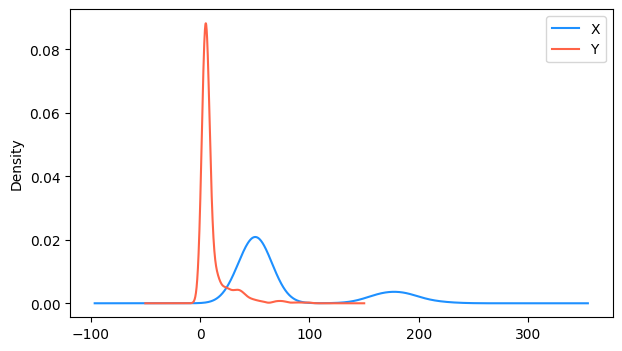

In [6]:
# Visualizar distribuciones de X y Y con una grafica
df_cluster[["X", "Y"]].plot(
    kind = "density",
    figsize = [7,4],
    color = ["dodgerblue","tomato"]
)
plt.show()

In [7]:
# Visualizar la distribución de frecuencias de los grupos
df_cluster["C"].value_counts().sort_index()

C
1      49
2    1393
3     346
4     211
Name: count, dtype: int64

Visualiza los datos mediante un gráfico de dispersión en el que las variables X y Y se encuentren en los ejes, y el color de los puntos sea el grupo (columna C) al que pertenecen. ESta es la segmentación que queremos conseguir con nuestro modelo.

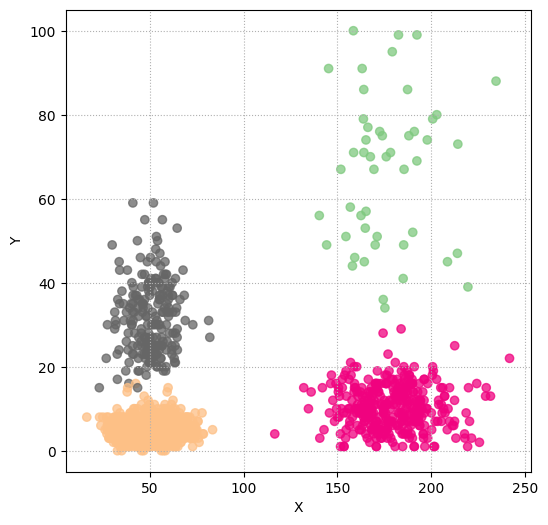

In [8]:
plt.figure(figsize = [6,6])
plt.scatter(
    x = df_cluster["X"],
    y = df_cluster["Y"],
    c = df_cluster["C"],
    alpha = 0.75,
    cmap = "Accent"
)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(linestyle = ":")
plt.show()

## Ejercicio 2

Renombra las columnas del dataset conforme los siguientes criterios:

| Nombre original | Nombre nuevo |
| ---- | ---- |
| X | v1 |
| Y | v2 |
| C | cluster |

In [9]:
df_cluster = df_cluster.rename(columns = {
    "X": "v1",
    "Y": "v2",
    "C": "cluster"
})
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   v1       1999 non-null   float64
 1   v2       1999 non-null   int64  
 2   cluster  1999 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 47.0 KB


Separa el dataset en atributos y variable objetivo.

In [10]:
X = df_cluster.drop(columns = "cluster")
y = df_cluster["cluster"]

Utilizando la función `MinMaxScaler`, normaliza los atributos a fin de evitar que el algoritmo a implementar se sesge por las magnitudes de las variables.

In [11]:
X[["v1", "v2"]] = MinMaxScaler().fit_transform(X[["v1", "v2"]])
X.describe().round(2)

,v1,v2
count,1999.00,1999.00
mean,0.26,0.10
std,0.23,0.13
min,0.00,0.00
25%,0.13,0.04
50%,0.17,0.06
75%,0.22,0.09
max,1.00,1.00


## Ejercicio 3


El algoritmo **K-Means** busca agrupar los atributos $X$ dado un número pre-definido de clústers $k$. Vamos a implementarlo paso a paso para luego contrastar los resultados alcanzados con los grupos reales.

Primero, define la variable `k` con el número de grupos que queremos crear, esto es, 4.

In [12]:
k = 4

A continuación selecciona de forma aleatoria $k$ observaciones aleatorias del conjunto de datos $X$. Utiliza el método `sample` con el argumento `random_state = 123` para que sean replicables tus cálculos, y guarda el resultado en la variable `centros`.

In [13]:
centros = X.sample(k, random_state = 123)
centros

,v1,v2
1341,0.188310,0.30
1337,0.272634,0.09
189,0.175972,0.06
1331,0.072475,0.00


Estima para cada observación de $X$ la distancia que mantiene con cada uno de los centros. Para esto considera que la distancia $d$ se puede obtener aplicando la siguiente fórmula:

$$ d = \sqrt{(v_1 - v_1^c)^2 + (v_2 - v_2^c)^2} $$

donde $v_1^c$ y $v_2^c$ son los valores de cada atributo correspondientes a un centro $c$.

Guarda el resultado en un dataframe llamado `distancias` que debería tener el mismo número de filas que $X$ y 4 columnas (una por cada distancia calculada a cada centro). Las columnas de este dataframe deben llamarse d1, d2, d3 y d4, respectivamente. 

In [14]:
distancias = []
for i in X.index:
    obs = X.loc[i]
    dist = []
    for c in centros.index:
        centro = centros.loc[c]
        d = np.sqrt(np.sum((obs - centro) ** 2))
        dist.append(d)    
    distancias.append(dist)
    
distancias = pd.DataFrame(distancias, columns = ["d1","d2","d3","d4"])
distancias.sample(10)

,d1,d2,d3,d4
388,0.255112,0.173438,0.074161,0.066788
997,0.281667,0.199042,0.098058,0.040697
334,0.439043,0.355087,0.456289,0.573277
632,0.276321,0.205946,0.105835,0.050035
1029,0.633929,0.538521,0.638494,0.751345
1286,0.248467,0.179442,0.082272,0.073327
1958,0.253484,0.168588,0.069235,0.069093
1721,0.622885,0.494945,0.591288,0.698219
545,0.081440,0.267540,0.249750,0.301965
1201,0.240156,0.097699,0.003684,0.122832


Utilizando el método `apply` y la función a continuación asigna el grupo al cual corresponde inicialmente cada observación en el dataframe **distancias**.

```py
def fun_grupo (row):
    if row["d1"] == min(row):
        return 1
    elif row["d2"] == min(row):
        return 2
    elif row["d3"] == min(row):
        return 3
    else:
        return 4
```

Nota que cada grupo inicial será definido por la distancia mínima a alguno de los centros aleatorios escogidos.

In [15]:
def fun_grupo (row):
    if row["d1"] == min(row):
        return 1
    elif row["d2"] == min(row):
        return 2
    elif row["d3"] == min(row):
        return 3
    else:
        return 4

distancias["grupo"] = distancias.apply(fun_grupo, axis = 1)
distancias.sample(10) 

,d1,d2,d3,d4,grupo
1725,0.292091,0.143564,0.054848,0.081567,3
286,0.266814,0.152660,0.051610,0.068754,3
1723,0.266762,0.203010,0.104119,0.060003,4
512,0.253627,0.133211,0.032004,0.088561,3
1044,0.220199,0.094221,0.020220,0.133177,3
1081,0.099136,0.299289,0.282221,0.330690,1
1495,0.245229,0.137998,0.038035,0.088799,3
283,0.503540,0.373336,0.470955,0.580514,2
1016,0.563980,0.451158,0.550104,0.661298,2
832,0.283516,0.146627,0.051335,0.074072,3


Crea nuevamente un gráfico de dispersión con los grupos iniciales encontrados para cada dato.

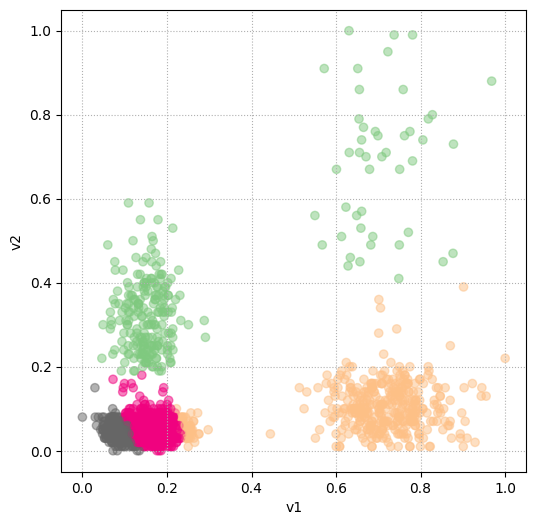

In [16]:
plt.figure(figsize = [6,6])
plt.scatter(
    x = X["v1"],
    y = X["v2"],
    c = distancias["grupo"],
    alpha = 0.5,
    cmap = "Accent"
)
plt.xlabel("v1")
plt.ylabel("v2")
plt.grid(linestyle = ":")
plt.show()

## Ejercicio 4

Como era de esperarse los grupos iniciales no parecen estar correctos. No te preocupes porque el algoritmo **K-Means** aún no termina.

Vuelve a calcular nuevos centros solamente que ahora determínalos como los **4 puntos promedio** de los grupos que acabas de obtener en el ejercicio anterior. Reemplaza la variable `centros` por este nuevo resultado.

In [17]:
X_temp = X.copy()
X_temp["grupo"] = distancias["grupo"]
centros = (
    X_temp
    .groupby("grupo")
    .agg(
        v1 = ("v1","mean"),
        v2 = ("v2","mean")
    )
)
centros

,v1,v2
grupo,,
1,0.253823,0.387024
2,0.665799,0.099446
3,0.162460,0.053736
4,0.089231,0.045862


Nuevamente calcula la distancia a estos nuevos centros y extrae grupos nuevos en base al criterio de distancia mínima ya expuesto.

In [18]:
# Calcular distancias
distancias = []
for i in X.index:
    obs = X.loc[i]
    dist = []
    for c in centros.index:
        centro = centros.loc[c]
        d = np.sqrt(np.sum((obs - centro)**2))
        dist.append(d)
    distancias.append(dist)

distancias = pd.DataFrame(distancias, columns = ["d1","d2","d3","d4"])
distancias.sample(5)

,d1,d2,d3,d4
398,0.377440,0.538924,0.039116,0.045024
1778,0.491975,0.054055,0.531271,0.604740
741,0.393138,0.530968,0.048109,0.064149
550,0.379417,0.514330,0.034078,0.073137
1013,0.327021,0.524938,0.033777,0.062196


In [19]:
# Estimar nuevos grupos
distancias["grupo"] = distancias.apply(fun_grupo, axis = 1)
distancias.sample(10) 

,d1,d2,d3,d4,grupo
1698,0.377498,0.539100,0.039257,0.044858,3
706,0.383649,0.556753,0.054505,0.028905,4
1487,0.353193,0.568435,0.066357,0.025725,4
1227,0.340975,0.510039,0.008124,0.069509,3
1284,0.350141,0.538540,0.034331,0.041930,3
1505,0.625716,0.127725,0.624852,0.698193,2
543,0.382842,0.554551,0.052517,0.030784,4
259,0.329024,0.449930,0.055496,0.129147,3
2,0.558634,0.115580,0.611096,0.684597,2
1419,0.337709,0.529170,0.029834,0.053922,3


Nuevamente visualiza en un gráfico de dispersión cómo queda el agrupamiento generado por el algoritmo.

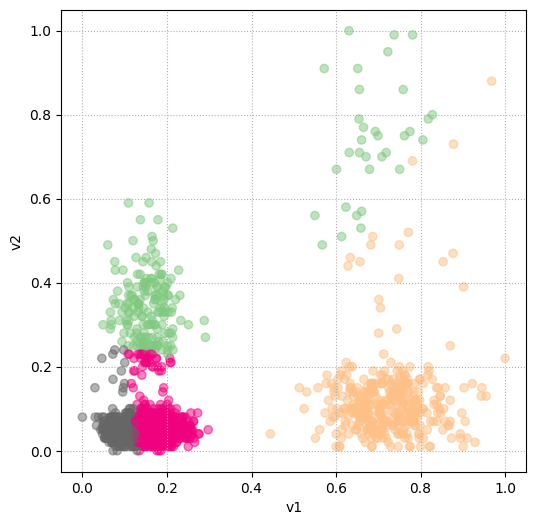

In [20]:
plt.figure(figsize = [6,6])
plt.scatter(
    x = X["v1"],
    y = X["v2"],
    c = distancias["grupo"],
    alpha = 0.5,
    cmap = "Accent"
)
plt.xlabel("v1")
plt.ylabel("v2")
plt.grid(linestyle = ":")
plt.show()

Estamos mejorando pero aún no logramos obtener los clusters deseados. Para finalizar esta parte, recalcula los centros en base a los nuevos grupos y su punto promedio.

In [21]:
X_temp = X.copy()
X_temp["grupo"] = distancias["grupo"]
centros = (
    X_temp
    .groupby("grupo")
    .agg(
        v1 = ("v1","mean"),
        v2 = ("v2","mean")
    )
)
centros

,v1,v2
grupo,,
1,0.241596,0.409701
2,0.724465,0.121409
3,0.171637,0.057444
4,0.096412,0.053747


## Ejercicio 5

Ya te habrás dado cuenta que este es un proceso iterativo que tiende a mejorar con cada recálculo de los centros y las distancias. Entonces, utiliza un bucle for de 25 ciclos para repetirlo.

In [22]:
for _ in range(25):

    # Calcular distancias
    distancias = []
    for i in X.index:
        obs = X.loc[i]
        dist = []
        for c in centros.index:
            centro = centros.loc[c]
            d = np.sqrt(np.sum((obs - centro)**2))
            dist.append(d)
        
        distancias.append(dist)

    distancias = pd.DataFrame(distancias, columns = ["d1","d2","d3","d4"])

    # Estimar nuevos grupos
    distancias["grupo"] = distancias.apply(fun_grupo, axis = 1)

    #Calcular centros
    X_temp = X.copy()
    X_temp["grupo"] = distancias["grupo"]
    centros = (
        X_temp
        .groupby("grupo")
        .agg(
            v1 = ("v1","mean"),
            v2 = ("v2","mean")
        )
    )

Visualiza con el gráfico de dispersión el agrupamiento alcanzado luego de estas 25 iteraciones.

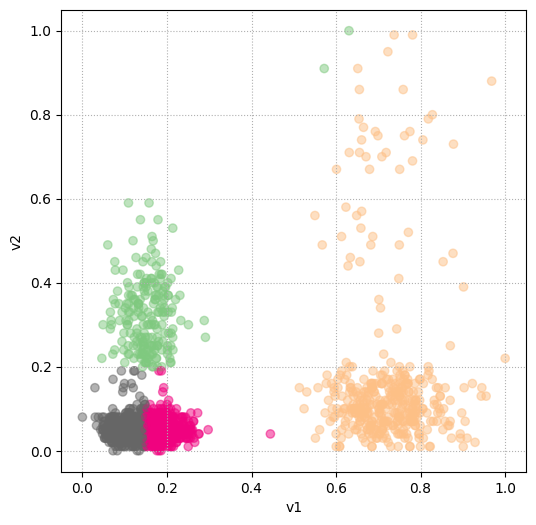

In [23]:
plt.figure(figsize = [6,6])
plt.scatter(
    x = X["v1"],
    y = X["v2"],
    c = distancias["grupo"],
    alpha = 0.5,
    cmap = "Accent"
)
plt.xlabel("v1")
plt.ylabel("v2")
plt.grid(linestyle = ":")
plt.show()

Luego de todo este trabajo, el agrupamiento aún no es el deseado, e incluso si repetimos el bucle durante más ciclos no lograremos grandes mejorías a lo que ya se ha alcanzado. La razón de este problema radica en uno de los primeros pasos: la selección inicial de centros aleatorios.

Intenta descubrir porqué este punto en nuestro proceso puede estar siendo problemático.

## Ejercicio 6

Una variante al algoritmo **K-Means** corrige el problema antes descrito y se llama **K-Means++**. Veamos cómo este segundo procedimiento define los centros iniciales.

Escoge una observación cualquiera del conjunto $X$ y guárdala en `centros`. Aplica nuevamente `random_state = 123` por replicabilidad.

In [24]:
centros = X.sample(1, random_state = 123)
centros

,v1,v2
1341,0.18831,0.3


Calcula la distancia de todas las observaciones respecto a este centro. Puedes reutilizar tu código anterior con unas ligeras modificaciones por lo que deberías generar un dataframe `distancias` nuevamente (solo que ahora con una columna pues tenemos un solo centro).

In [25]:
distancias = []
for i in X.index:
    obs = X.loc[i]
    dist = []
    for c in centros.index:
        centro = centros.loc[c]
        d = np.sqrt(np.sum((obs - centro)**2))
        dist.append(d)
    
    distancias.append(dist)

distancias = pd.DataFrame(distancias, columns = ["d1"])
distancias.sample(5)

,d1
1695,0.613111
115,0.278246
1062,0.588100
1119,0.050507
1870,0.455200


Selecciona los 10 casos con la mayor distancia y guarda sus índices en la variable `c2`.

In [26]:
candidatos = distancias.sort_values(by = "d1", ascending = False).head(10)
c2 = candidatos.index

Utilizando estos índices, extrae el nuevo centro desde $X$ como el valor promedio de los atributos correspondientes y adiciónalo en `centros`.

In [27]:
centros = pd.concat([centros, X.loc[c2].mean().to_frame().transpose()])
centros = centros.reset_index(drop = True)
centros

,v1,v2
0,0.188310,0.300
1,0.812254,0.821


Vuelve a recalcular las distancias de las observaciones con respecto a estos centros en un dataframe `distancias` (ahora deberías obtener dos columnas por los dos centros).

In [28]:
distancias = []
for i in X.index:
    obs = X.loc[i]
    dist = []
    for c in centros.index:
        centro = centros.loc[c]
        d = np.sqrt(np.sum((obs - centro)**2))
        dist.append(d)
    
    distancias.append(dist)

distancias = pd.DataFrame(distancias, columns = ["d1", "d2"])
distancias.sample(5)

,d1,d2
850,0.260256,1.038872
1167,0.516538,0.673041
733,0.242279,1.005434
489,0.100328,0.795211
1047,0.290460,1.033283


Calcula en una nueva columna el producto de las dos distancias obtenidas para cada registro.

In [29]:
distancias["d_prod"] = distancias.apply(lambda x: np.prod(x), axis = 1)
distancias.sample(5)

,d1,d2,d_prod
814,0.246140,1.019602,0.250965
1888,0.277127,1.047287,0.290231
30,0.240001,0.983665,0.236080
831,0.215470,0.993074,0.213978
1540,0.475799,0.757079,0.360217


Selecciona los 10 casos con la mayor "distancia producto" y guarda sus índices en `c3`.

In [30]:
candidatos = distancias.sort_values(by = "d_prod", ascending = False).head(10)
c3 = candidatos.index

Utilizando estos índices extrae el nuevo centro desde $X$ como el promedio de los atributos correspondientes e incorpóralo como una fila adicional en `centros`.

In [31]:
centros = pd.concat([centros,X.loc[c3].mean().to_frame().transpose()])
centros = centros.reset_index(drop = True)
centros

,v1,v2
0,0.188310,0.300
1,0.812254,0.821
2,0.890529,0.038


Ya debes tener una noción de qué estamos haciendo aquí. Utiliza el mismo procedimiento para obtener el último centro inicial.

In [32]:
# Calcular distancias con centros
distancias = []
for i in X.index:
    obs = X.loc[i]
    dist = []
    for c in centros.index:
        centro = centros.loc[c]
        d = np.sqrt(np.sum((obs - centro)**2))
        dist.append(d)
    
    distancias.append(dist)

distancias = pd.DataFrame(distancias, columns = ["d1", "d2", "d3"])
distancias.sample(5)

,d1,d2,d3
183,0.261082,1.014623,0.725966
1542,0.242031,1.026171,0.778237
1819,0.469696,0.694425,0.280453
1048,0.220174,0.963095,0.694747
941,0.590361,0.734556,0.159202


In [33]:
# Obtener distancias producto
distancias["d_prod"] = distancias.apply(lambda x: np.prod(x), axis = 1)
distancias.sample(5)

,d1,d2,d3,d_prod
1933,0.230159,0.981870,0.711505,0.160791
241,0.576594,0.788611,0.187584,0.085296
432,0.241701,1.002481,0.731176,0.177165
1524,0.260338,1.007969,0.715492,0.187754
776,0.280668,1.056649,0.778907,0.230999


In [34]:
# Extraer indices de las 10 mayores distancias producto
candidatos = distancias.sort_values(by = "d_prod", ascending = False).head(10)
c4 = candidatos.index

# Incluir nuevo centro
centros = pd.concat([centros,X.loc[c4].mean().to_frame().transpose()])
centros = centros.reset_index(drop = True)
centros

,v1,v2
0,0.188310,0.300
1,0.812254,0.821
2,0.890529,0.038
3,0.058468,0.025


## Ejercicio 7

Ya tenemos los nuevos centros iniciales. Vuelve a ejecutar el bucle `for` del ejercicio 5 para ver si mejora la sementación resultante con este algoritmo. 

In [35]:
for _ in range(25):

    # Calcular distancias
    distancias = []
    for i in X.index:
        obs = X.loc[i]
        dist = []
        for c in centros.index:
            centro = centros.loc[c]
            d = np.sqrt(np.sum((obs - centro)**2))
            dist.append(d)
        
        distancias.append(dist)

    distancias = pd.DataFrame(distancias, columns = ["d1","d2","d3","d4"])

    # Estimar nuevos grupos
    distancias["grupo"] = distancias.apply(fun_grupo, axis = 1)

    #Calcular centros
    X_temp = X.copy()
    X_temp["grupo"] = distancias["grupo"]
    centros = (
        X_temp
        .groupby("grupo")
        .agg(
            v1 = ("v1","mean"),
            v2 = ("v2","mean")
        )
    )

Visualiza los resultados con el gráfico de dispersión correspondiente.

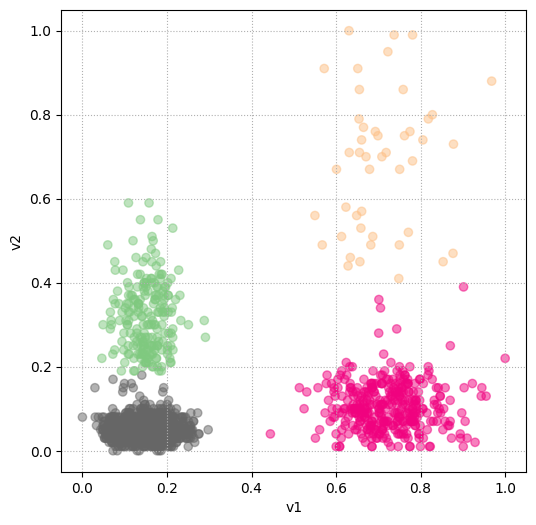

In [36]:
plt.figure(figsize = [6,6])
plt.scatter(
    x = X["v1"],
    y = X["v2"],
    c = distancias["grupo"],
    alpha = 0.5,
    cmap = "Accent"
)
plt.xlabel("v1")
plt.ylabel("v2")
plt.grid(linestyle = ":")
plt.show()

El resultado es significativamente mejor gracias a una definición de centros iniciales más coherente. En efecto, el algoritmo **K-Means++** básicamente establece que para una mejor segmentación, los centros iniciales deben estar lo más separados posibles uno del otro.

## Ejercicio 8

Ahora que ya conocemos cómo funciona este algoritmo, veamos su implementación directamente con **Scikit-Learn**. Importa para esto la función `KMeans` del módulo `cluster`, así como todo el módulo `metrics`. 

In [37]:
from sklearn.cluster import KMeans
from sklearn import metrics

Crea y entrena un modelo con este algoritmo. Incluye el argumento `n_clusters` con la cantidad de grupos deseados, esto es, 4.

In [38]:
# Crear modelo
mod_kmean = KMeans(n_clusters = k)

# Entrenar modelo
mod_kmean.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Genera predicciones a partir de las observaciones del conjunto $X$.

In [39]:
c_pred = mod_kmean.predict(X)

Visualiza los resultados alcanzados con el gráfico de dispersión correspondiente.

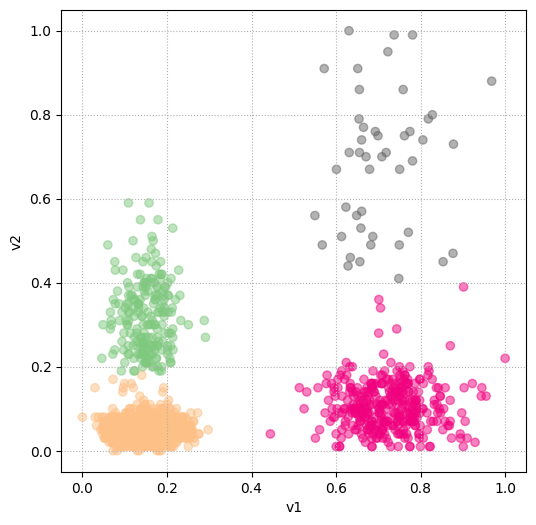

In [40]:
plt.figure(figsize = [6,6])
plt.scatter(
    x = X["v1"],
    y = X["v2"],
    c = c_pred,
    alpha = 0.5,
    cmap = "Accent"
)
plt.xlabel("v1")
plt.ylabel("v2")
plt.grid(linestyle = ":")
plt.show()

Para finalizar, evalua el rendimiento de este algoritmo con las métricas **Silueta**, **DBI** y **CHI**. 

In [41]:
sil = metrics.silhouette_score(X, c_pred)
dbi = metrics.davies_bouldin_score(X, c_pred)
chi = metrics.calinski_harabasz_score(X, c_pred)
print(f"Silueta: {sil:.1%}")
print(f"DBI: {dbi:.1f}")
print(f"CHI: {chi:.1f}")

Silueta: 74.8%
DBI: 0.5
CHI: 8395.1
